# Random Testing

Here we will run some tests on randomly generated weak deterministic Büchi automata (wDBA) and plot some results.

Precomputed results for the default parameters are included in the `data` folder, and will be used by default.

In [1]:
from sproutcex.random_testing import perform_sample_test
from sproutcex.utils import plot_param_with_power_fit

## General runtime analysis

To analyze the general performance on a set of random wDBA will use a large sample of $50.000$ wDBA of size $|Q| \leq 25$ with a alphabet size $2 \leq |\Sigma| \leq 4$.
The results are grouped by alphabet size $|\Sigma|$ and a power-law regression fit is performed.

First we display the average number of equivalence queries (EQs) in relation to the size, then the maximum number of EQs.
We have filtered the maximum values to increase monotonically, such that it is the true maximum for any automaton up to that size.

Processing automata: 100%|##########| 50000/50000 [00:00<?, ?it/s]

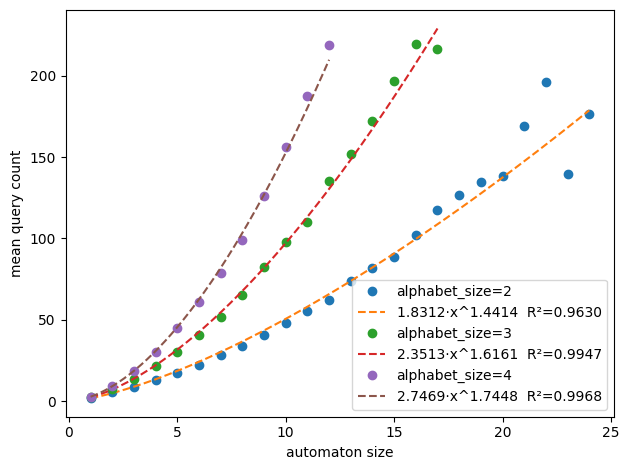

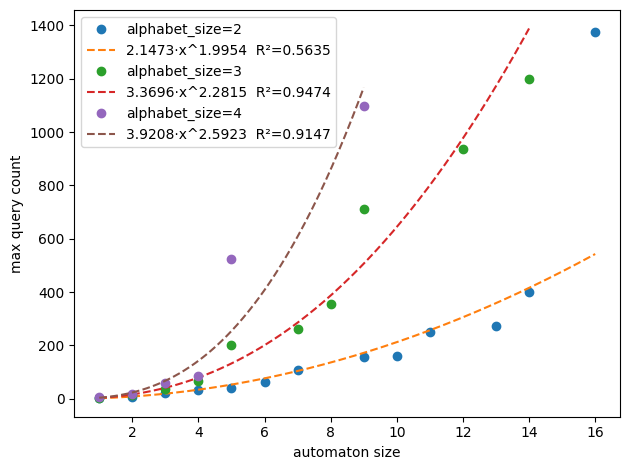

In [2]:
# run test
df, automata = perform_sample_test(42, 50000)

# plot results
plot_param_with_power_fit(df)
plot_param_with_power_fit(df, criterion="max", monotonic=True)

## Comparing Cons Methods

We will now loop at a smaller set of $2.000$ wDBA and compare the performance of **BuchiCons** and **weakBuchiCons**.
Unlike **BuchiCons**, **weakBuchiCons** makes sure that every guess is also weak.

Processing automata: 100%|##########| 4000/4000 [00:00<?, ?it/s]

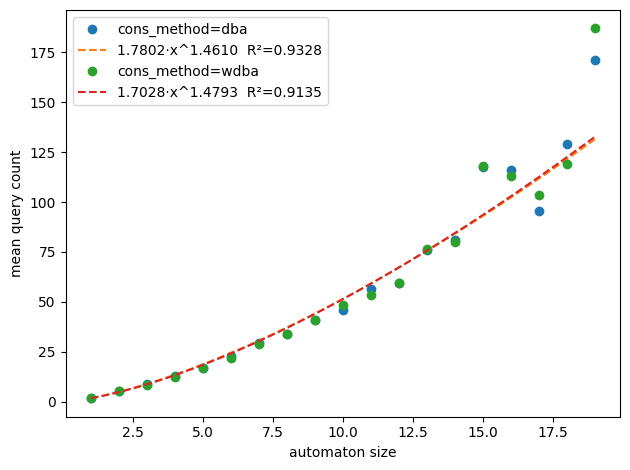

In [3]:
# run tests
df, automata = perform_sample_test(42, 2000, alphabet_high=2, state_high=20,
                                   grid_parameters={"cons_method": ["dba", "wdba"]})

# plot results
plot_param_with_power_fit(df, group_by="cons_method")

## Comparing Orderings of Ultimately Periodic Word

Here we compare the results for 4 different orderings of ultimately periodic words.

+ Default: $(|u v|, |v|, (u v)_{lex})$.
+ Prefix: $(|u v|, |u|, (u v)_{lex})$.
+ $\omega$-expansion: $(|u v|, (u v^\omega)_{lex})$.
+ Length-lexicographic:  $(|u v|, (u v)_{lex}, |v|)$.


Processing automata: 100%|##########| 8000/8000 [00:00<?, ?it/s]

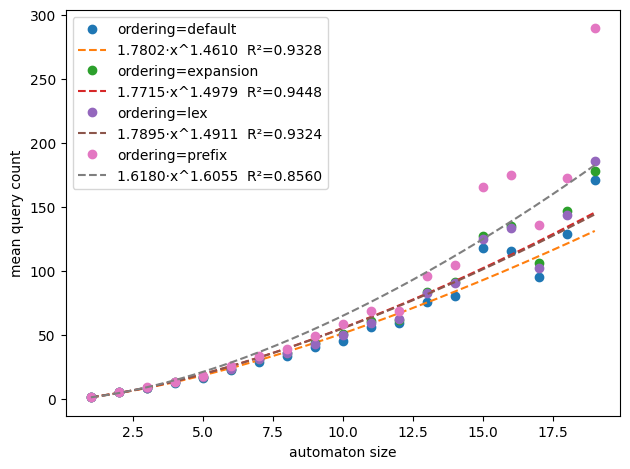

In [4]:
df, automata = perform_sample_test(42, 2000, alphabet_high=2, state_high=20,
                                   grid_parameters={
                                       "ordering": ["default", "prefix", "lex",
                                                    "expansion"]})

plot_param_with_power_fit(df, group_by="ordering")

## Comparing Different Thresholds

We compare two different thresholds after which **Sprout** will abort and terminate using **Expand**.

- Square: $\max_{u v^\omega \in S} |u| + \max_{u v^\omega \in S} |v|^2 + 1$.
- Linear: $2 \cdot \max_{u v^\omega in S} |u v|$.

Processing automata: 100%|##########| 4000/4000 [00:00<?, ?it/s]

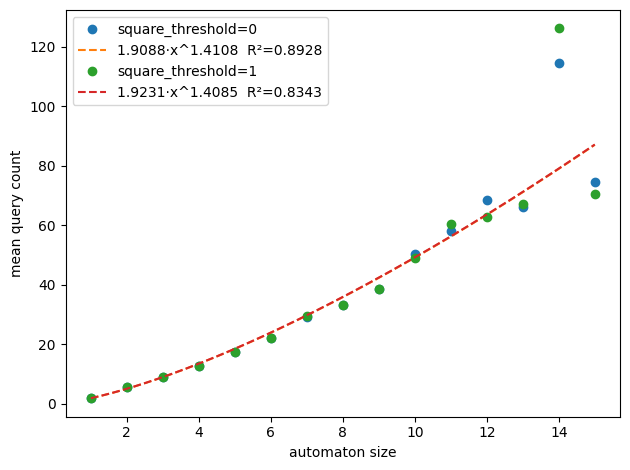

In [5]:
df, automata = perform_sample_test(42, 2000, alphabet_high=2, state_high=15,
                                   grid_parameters={"square_threshold": [True, False]},
                                   core_count=10)

plot_param_with_power_fit(df, group_by="square_threshold")